In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import save_image
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import time
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("✅ Imports done!")

Using device: cuda
✅ Imports done!


In [2]:
import os

for dirname, dirs, filenames in os.walk('/kaggle/input'):
    print(f"Folder: {dirname}")
    for f in filenames[:3]:
        print(f"  File: {f}")
    if dirname != '/kaggle/input':
        break

Folder: /kaggle/input
Folder: /kaggle/input/datasets


In [3]:
import os

for dirname, dirs, filenames in os.walk('/kaggle/input/datasets'):
    print(f"Folder: {dirname}")
    for f in filenames[:3]:
        print(f"  File: {f}")

Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/anjaliikakde
Folder: /kaggle/input/datasets/anjaliikakde/paired-sar-optical-dataset-16k-images
Folder: /kaggle/input/datasets/anjaliikakde/paired-sar-optical-dataset-16k-images/Paired_SAR_Optical_images
  File: ROIs1970_fall_s1_114_p14.png
  File: ROIs1970_fall_s1_114_p270.png
  File: ROIs1970_fall_s1_19_p924.png


In [4]:
# class SAROpticalDataset(Dataset):
#     def __init__(self, data_dir, img_size=256):
#         self.data_dir = data_dir
#         self.files = sorted([f for f in os.listdir(data_dir) 
#                            if f.endswith('.png')])
#         self.img_size = img_size
#         print(f"Found {len(self.files)} images")

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         img_path = os.path.join(self.data_dir, self.files[idx])
#         img = Image.open(img_path).convert('RGB')
        
#         w, h = img.size
#         half_w = w // 2
        
#         sar_img = img.crop((0, 0, half_w, h))
#         opt_img = img.crop((half_w, 0, w, h))

#         resize    = transforms.Resize((self.img_size, self.img_size))
#         sar_img   = resize(sar_img)
#         opt_img   = resize(opt_img)

#         to_tensor = transforms.ToTensor()
#         normalize = transforms.Normalize([0.5]*3, [0.5]*3)

#         sar_tensor = normalize(to_tensor(sar_img)).mean(dim=0, keepdim=True)
#         opt_tensor = normalize(to_tensor(opt_img))

#         return sar_tensor, opt_tensor

# # Correct path!
# data_dir   = '/kaggle/input/datasets/anjaliikakde/paired-sar-optical-dataset-16k-images/Paired_SAR_Optical_images'
# dataset    = SAROpticalDataset(data_dir)
# dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

# sar_batch, opt_batch = next(iter(dataloader))
# print(f"SAR shape:     {sar_batch.shape}")
# print(f"Optical shape: {opt_batch.shape}")
# print("✅ Dataset ready!")

In [5]:
from torch.utils.data import Subset 

class SAROpticalDataset(Dataset):
    def __init__(self, data_dir, img_size=256):
        self.data_dir = data_dir
        self.files = sorted([f for f in os.listdir(data_dir) 
                           if f.endswith('.png')])
        self.img_size = img_size
        print(f"Found {len(self.files)} images")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.files[idx])
        img = Image.open(img_path).convert('RGB')
        w, h = img.size
        half_w = w // 2
        sar_img = img.crop((0, 0, half_w, h))
        opt_img = img.crop((half_w, 0, w, h))
        resize    = transforms.Resize((self.img_size, self.img_size))
        sar_img   = resize(sar_img)
        opt_img   = resize(opt_img)
        to_tensor = transforms.ToTensor()
        normalize = transforms.Normalize([0.5]*3, [0.5]*3)
        sar_tensor = normalize(to_tensor(sar_img)).mean(dim=0, keepdim=True)
        opt_tensor = normalize(to_tensor(opt_img))
        return sar_tensor, opt_tensor

# Path
data_dir = '/kaggle/input/datasets/anjaliikakde/paired-sar-optical-dataset-16k-images/Paired_SAR_Optical_images'

# Dataset load 
dataset    = SAROpticalDataset(data_dir)
dataset    = Subset(dataset, range(5000))  # ←5000 images
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

# Test
sar_batch, opt_batch = next(iter(dataloader))
print(f"SAR shape:     {sar_batch.shape}")
print(f"Optical shape: {opt_batch.shape}")
print("✅ Dataset ready!")

Found 15999 images
SAR shape:     torch.Size([4, 1, 256, 256])
Optical shape: torch.Size([4, 3, 256, 256])
✅ Dataset ready!


In [6]:
# =============================================
# GENERATOR
# =============================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down:
            layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
        else:
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return torch.relu(self.block(x))

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = nn.Conv2d(1, 64, 4, 2, 1)
        self.e2 = ConvBlock(64,  128)
        self.e3 = ConvBlock(128, 256)
        self.e4 = ConvBlock(256, 512)
        self.e5 = ConvBlock(512, 512)
        self.e6 = ConvBlock(512, 512)
        self.e7 = ConvBlock(512, 512)
        self.bottleneck = nn.Sequential(nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU())
        self.d1 = ConvBlock(512,  512, down=False, dropout=True)
        self.d2 = ConvBlock(1024, 512, down=False, dropout=True)
        self.d3 = ConvBlock(1024, 512, down=False, dropout=True)
        self.d4 = ConvBlock(1024, 512, down=False)
        self.d5 = ConvBlock(1024, 256, down=False)
        self.d6 = ConvBlock(512,  128, down=False)
        self.d7 = ConvBlock(256,  64,  down=False)
        self.output = nn.Sequential(nn.ConvTranspose2d(128, 3, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        b  = self.bottleneck(e7)
        d1 = self.d1(b)
        d2 = self.d2(torch.cat([d1, e7], dim=1))
        d3 = self.d3(torch.cat([d2, e6], dim=1))
        d4 = self.d4(torch.cat([d3, e5], dim=1))
        d5 = self.d5(torch.cat([d4, e4], dim=1))
        d6 = self.d6(torch.cat([d5, e3], dim=1))
        d7 = self.d7(torch.cat([d6, e2], dim=1))
        return self.output(torch.cat([d7, e1], dim=1))

# =============================================
# DISCRIMINATOR
# =============================================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, sar, optical):
        return self.model(torch.cat([sar, optical], dim=1))



In [7]:
# =============================================
# TRAINING
# =============================================
G = Generator().to(device)
D = Discriminator().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1  = nn.L1Loss()
optimizer_G   = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D   = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

LAMBDA_L1  = 100
NUM_EPOCHS = 50
save_dir   = '/kaggle/working/Results'
os.makedirs(save_dir, exist_ok=True)
os.makedirs(f"{save_dir}/checkpoints", exist_ok=True)

print("🚀 Starting Training...")

for epoch in range(NUM_EPOCHS):
    G.train()
    D.train()
    epoch_loss_G = 0
    epoch_loss_D = 0
    start = time.time()

    for i, (sar, optical) in enumerate(dataloader):
        sar     = sar.to(device)
        optical = optical.to(device)

        optimizer_D.zero_grad()
        real_pred   = D(sar, optical)
        loss_D_real = criterion_GAN(real_pred, torch.ones_like(real_pred))
        fake_optical = G(sar)
        fake_pred    = D(sar, fake_optical.detach())
        loss_D_fake  = criterion_GAN(fake_pred, torch.zeros_like(fake_pred))
        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        fake_optical = G(sar)
        pred_fake    = D(sar, fake_optical)
        loss_G = criterion_GAN(pred_fake, torch.ones_like(pred_fake)) + \
                 criterion_L1(fake_optical, optical) * LAMBDA_L1
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

    elapsed = time.time() - start
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Loss_G: {epoch_loss_G/len(dataloader):.4f}  "
          f"Loss_D: {epoch_loss_D/len(dataloader):.4f}  "
          f"Time: {elapsed:.1f}s")

    if (epoch + 1) % 5 == 0:
        G.eval()
        with torch.no_grad():
            s_sar, s_opt = next(iter(dataloader))
            fake = (G(s_sar.to(device)) + 1) / 2
            real = (s_opt + 1) / 2
            save_image(fake, f"{save_dir}/fake_epoch_{epoch+1}.png")
            save_image(real, f"{save_dir}/real_epoch_{epoch+1}.png")
            print(f"💾 Saved samples at epoch {epoch+1}")

    if (epoch + 1) % 10 == 0:
        torch.save(G.state_dict(), f"{save_dir}/checkpoints/G_epoch_{epoch+1}.pth")
        torch.save(D.state_dict(), f"{save_dir}/checkpoints/D_epoch_{epoch+1}.pth")
        print(f"💾 Checkpoint saved at epoch {epoch+1}")

print("✅ Training Complete!")

🚀 Starting Training...
Epoch [1/50] Loss_G: 38.2367  Loss_D: 0.2561  Time: 246.7s
Epoch [2/50] Loss_G: 36.3756  Loss_D: 0.2898  Time: 257.4s
Epoch [3/50] Loss_G: 34.8241  Loss_D: 0.2734  Time: 256.5s
Epoch [4/50] Loss_G: 32.8072  Loss_D: 0.2752  Time: 256.7s
Epoch [5/50] Loss_G: 31.4698  Loss_D: 0.2625  Time: 257.0s
💾 Saved samples at epoch 5
Epoch [6/50] Loss_G: 30.2862  Loss_D: 0.2302  Time: 256.3s
Epoch [7/50] Loss_G: 29.0121  Loss_D: 0.2403  Time: 257.2s
Epoch [8/50] Loss_G: 27.6872  Loss_D: 0.2535  Time: 256.7s
Epoch [9/50] Loss_G: 26.6150  Loss_D: 0.2738  Time: 256.9s
Epoch [10/50] Loss_G: 25.8850  Loss_D: 0.2641  Time: 256.1s
💾 Saved samples at epoch 10
💾 Checkpoint saved at epoch 10
Epoch [11/50] Loss_G: 25.4429  Loss_D: 0.2506  Time: 256.9s
Epoch [12/50] Loss_G: 25.0122  Loss_D: 0.2416  Time: 256.3s
Epoch [13/50] Loss_G: 24.1017  Loss_D: 0.2578  Time: 256.3s
Epoch [15/50] Loss_G: 22.1872  Loss_D: 0.3354  Time: 255.9s
💾 Saved samples at epoch 15
Epoch [16/50] Loss_G: 22.4719  L

In [8]:
import shutil

shutil.make_archive(
    "gan_checkpoints",          # zip file name
    'zip',
    "/kaggle/working/Results/checkpoints"
)

print("✅ Checkpoints zipped successfully")

✅ Checkpoints zipped successfully


In [9]:
from IPython.display import FileLink

FileLink("gan_checkpoints.zip")

/kaggle/working/gan_checkpoints.zip

In [10]:
import shutil

shutil.make_archive(
    "gan_full_results",
    'zip',
    "/kaggle/working/Results"
)

print("✅ Full results zipped")

✅ Full results zipped


In [11]:
from IPython.display import FileLink

FileLink("gan_full_results.zip")

/kaggle/working/gan_full_results.zip

In [13]:
import os

os.listdir("/kaggle/working")

['.virtual_documents',
 '.ipynb_checkpoints',
 'gan_full_results.zip',
 'gan_checkpoints.zip',
 'Results']

In [17]:
import os

path = "/kaggle/working/Results/checkpoints"

print("Files inside checkpoints folder:\n")
print(os.listdir(path))

Files inside checkpoints folder:

['G_epoch_50.pth', 'G_epoch_20.pth', 'D_epoch_10.pth', 'G_epoch_30.pth', 'D_epoch_20.pth', 'D_epoch_40.pth', 'G_epoch_10.pth', 'G_epoch_40.pth', 'D_epoch_30.pth', 'D_epoch_50.pth']


✅ Model loaded from: /kaggle/working/Results/checkpoints/G_epoch_50.pth


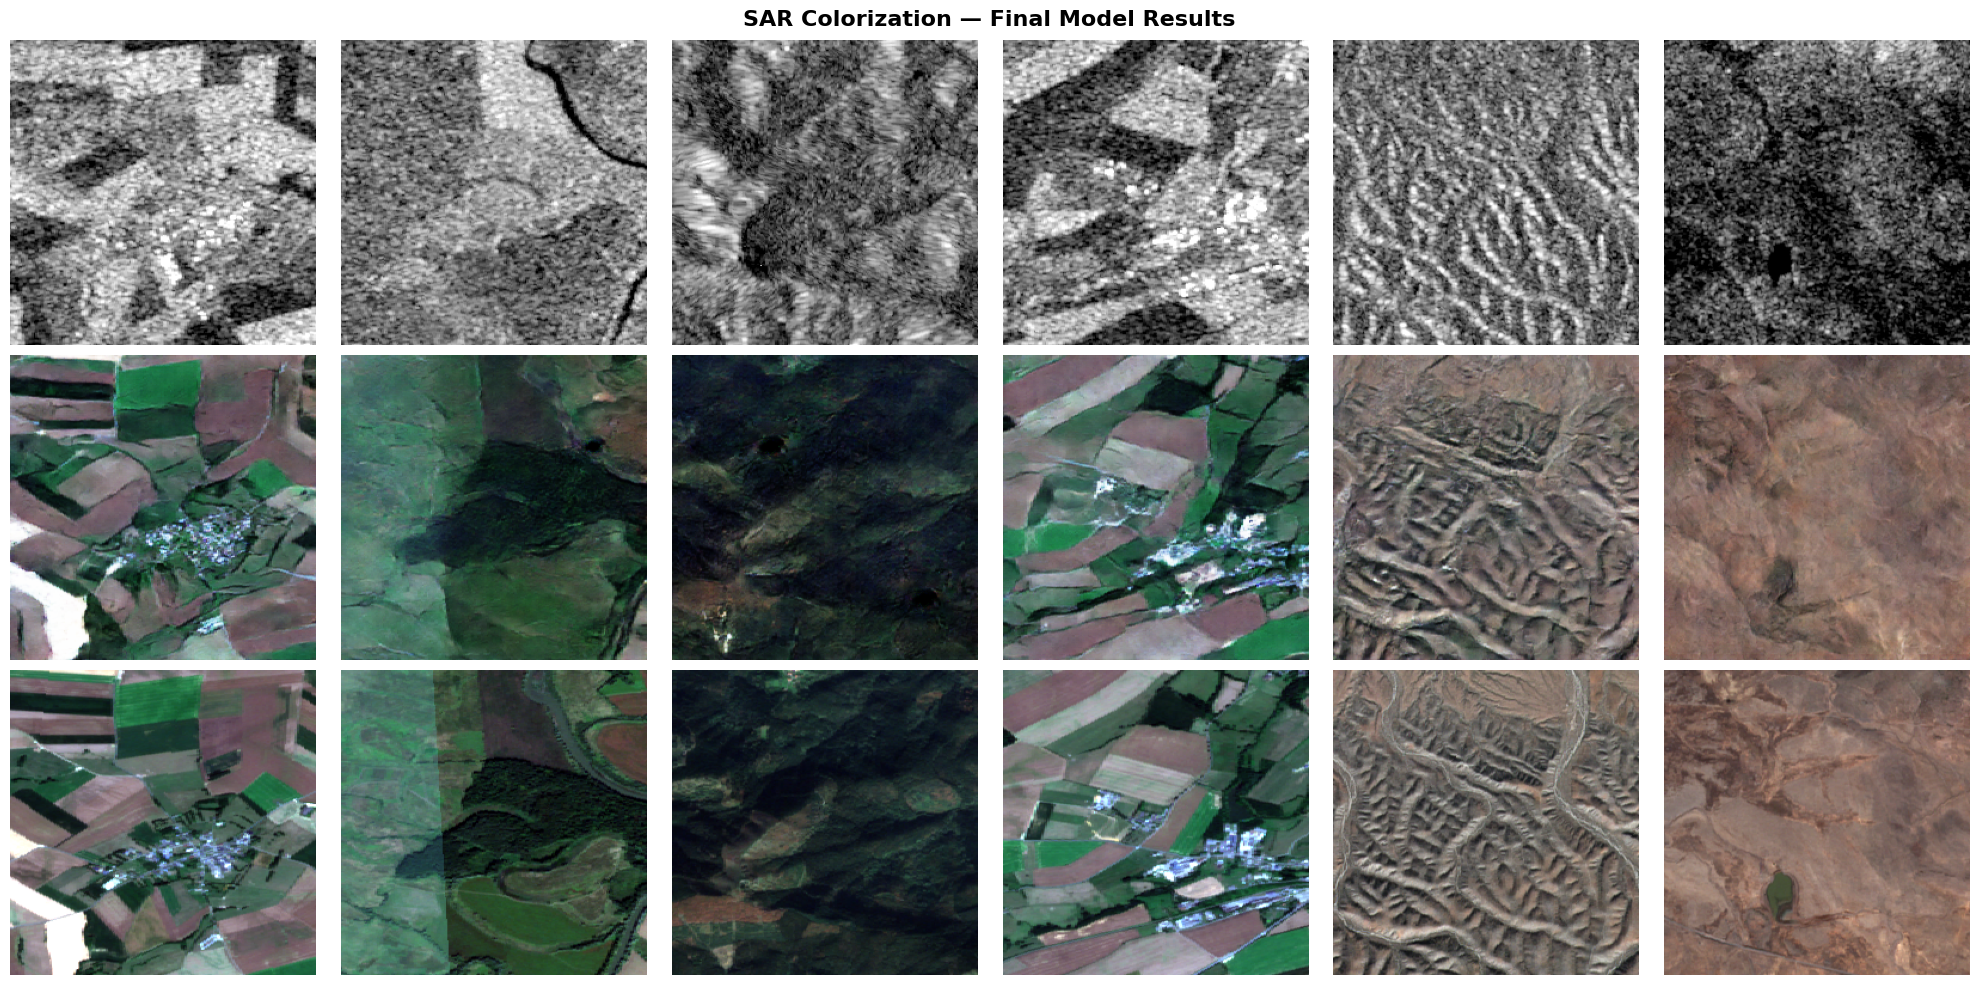

✅ Evaluation saved to: Results/evaluation.png

📊 Evaluation Metrics (200 samples):
PSNR : 20.85 dB
SSIM : 0.4497


In [18]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torchvision.utils import save_image
import os

# =============================================
# Device
# =============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# Load saved checkpoint
# =============================================
checkpoint_path = "/kaggle/working/Results/checkpoints/G_epoch_50.pth"
G_eval = Generator().to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

# If your checkpoint stored dict
if "generator_state_dict" in checkpoint:
    G_eval.load_state_dict(checkpoint["generator_state_dict"])
else:
    G_eval.load_state_dict(checkpoint)

G_eval.eval()

print("✅ Model loaded from:", checkpoint_path)

# =============================================
# Evaluate on 6 samples
# =============================================
fig, axes = plt.subplots(3, 6, figsize=(20, 10))

sample_count = 0

with torch.no_grad():
    for sar_batch, opt_batch in dataloader:

        sar_batch = sar_batch.to(device)
        fake_batch = G_eval(sar_batch)

        for i in range(min(4, sar_batch.size(0))):

            if sample_count >= 6:
                break

            # SAR INPUT
            sar_img = sar_batch[i].cpu().squeeze().numpy()

            axes[0, sample_count].imshow(
                sar_img,
                cmap="gray"
            )
            axes[0, sample_count].axis("off")

            if sample_count == 0:
                axes[0, 0].set_ylabel(
                    "SAR Input",
                    fontsize=12
                )

            # GENERATED IMAGE
            fake_img = (
                fake_batch[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
                + 1
            ) / 2

            fake_img = np.clip(fake_img, 0, 1)

            axes[1, sample_count].imshow(fake_img)
            axes[1, sample_count].axis("off")

            if sample_count == 0:
                axes[1, 0].set_ylabel(
                    "Generated",
                    fontsize=12
                )

            # GROUND TRUTH
            real_img = (
                opt_batch[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
                + 1
            ) / 2

            real_img = np.clip(real_img, 0, 1)

            axes[2, sample_count].imshow(real_img)
            axes[2, sample_count].axis("off")

            if sample_count == 0:
                axes[2, 0].set_ylabel(
                    "Ground Truth",
                    fontsize=12
                )

            sample_count += 1

        if sample_count >= 6:
            break

plt.suptitle(
    "SAR Colorization — Final Model Results",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

save_path = "Results/evaluation.png"

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Evaluation saved to:", save_path)

# =============================================
# Calculate PSNR & SSIM
# =============================================
from skimage.metrics import (
    peak_signal_noise_ratio as psnr,
    structural_similarity as ssim
)

psnr_scores = []
ssim_scores = []

with torch.no_grad():

    for sar_batch, opt_batch in dataloader:

        sar_batch = sar_batch.to(device)

        fake_batch = G_eval(sar_batch)

        for i in range(sar_batch.size(0)):

            fake = (
                fake_batch[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
                + 1
            ) / 2

            real = (
                opt_batch[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
                + 1
            ) / 2

            fake = np.clip(fake, 0, 1)
            real = np.clip(real, 0, 1)

            psnr_scores.append(
                psnr(real, fake, data_range=1.0)
            )

            ssim_scores.append(
                ssim(
                    real,
                    fake,
                    data_range=1.0,
                    channel_axis=2
                )
            )

        if len(psnr_scores) >= 200:
            break

print("\n📊 Evaluation Metrics (200 samples):")

print(
    f"PSNR : {np.mean(psnr_scores):.2f} dB"
)

print(
    f"SSIM : {np.mean(ssim_scores):.4f}"
)